In [1]:
!pip install seaborn -q

In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported")

All libraries imported


In [3]:
# data load karo
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# cleaning
data = df.copy()
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Embarked'] = data['Embarked'].fillna('S')
data = data.drop(['Cabin', 'Ticket', 'Name', 'PassengerId'], axis=1)

enc = LabelEncoder()
data['Sex'] = enc.fit_transform(data['Sex'])
data['Embarked'] = enc.fit_transform(data['Embarked'])
data = data.dropna()

print("Data shape:", data.shape)
data.head()

Data shape: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [5]:
X = data.drop('Survived', axis=1)
y = data['Survived']

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

print(f"Logistic Regression Accuracy: {lr_acc*100:.1f}%")
print(f"Decision Tree Accuracy:       {dt_acc*100:.1f}%")

Logistic Regression Accuracy: 81.0%
Decision Tree Accuracy:       79.9%


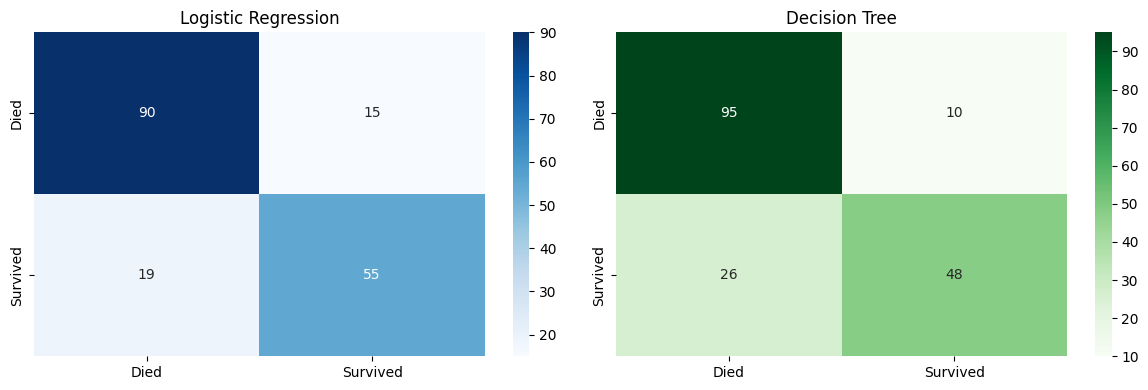

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# LR confusion matrix
cm1 = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
axes[0].set_title('Logistic Regression')

# DT confusion matrix
cm2 = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
axes[1].set_title('Decision Tree')

plt.tight_layout()
plt.show()

In [ ]:
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, target_names=['Died', 'Survived']))

print("=== Decision Tree ===")
print(classification_report(y_test, dt_pred, target_names=['Died', 'Survived']))

=== Logistic Regression ===
              precision    recall  f1-score   support

        Died       0.83      0.86      0.84       105
    Survived       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

=== Decision Tree ===
              precision    recall  f1-score   support

        Died       0.79      0.90      0.84       105
    Survived       0.83      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.78       179
weighted avg       0.80      0.80      0.79       179



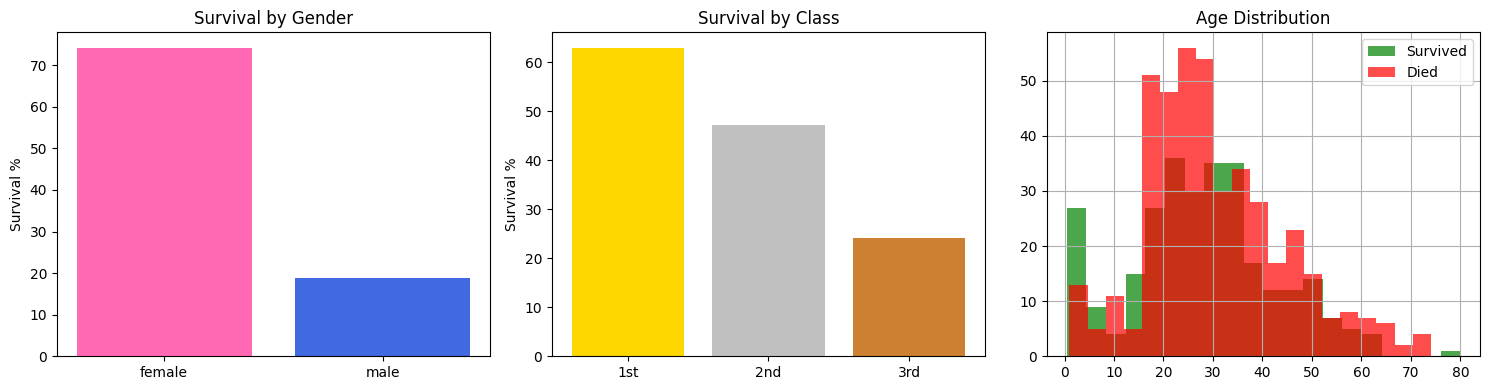

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gender survival
surv_gender = df.groupby('Sex')['Survived'].mean() * 100
axes[0].bar(surv_gender.index, surv_gender.values, color=['#ff69b4', '#4169e1'])
axes[0].set_title('Survival by Gender')
axes[0].set_ylabel('Survival %')

# Class survival
surv_class = df.groupby('Pclass')['Survived'].mean() * 100
axes[1].bar(['1st', '2nd', '3rd'], surv_class.values, color=['gold', 'silver', '#cd7f32'])
axes[1].set_title('Survival by Class')
axes[1].set_ylabel('Survival %')

# Age distribution
df[df['Survived']==1]['Age'].dropna().hist(ax=axes[2], bins=20, alpha=0.7, color='green', label='Survived')
df[df['Survived']==0]['Age'].dropna().hist(ax=axes[2], bins=20, alpha=0.7, color='red', label='Died')
axes[2].set_title('Age Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# test passenger - Female, 1st class, age 25
test_passenger = np.array([[1, 0, 25, 0, 0, 100, 2]])

lr_result = lr_model.predict(test_passenger)[0]
dt_result = dt_model.predict(test_passenger)[0]

print("Test Passenger: Female, 1st Class, Age 25")
print(f"Logistic Regression: {'✅ Survived' if lr_result==1 else '❌ Died'}")
print(f"Decision Tree:       {'✅ Survived' if dt_result==1 else '❌ Died'}")

Test Passenger: Female, 1st Class, Age 25
Logistic Regression: ✅ Survived
Decision Tree:       ✅ Survived
